In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
df = pd.read_csv(r'C:\Users\DELL\Downloads\Eda_project\Diwali Sales Data.csv', encoding= 'unicode_escape')
#to avoid encoding erros, use unicode_escape

### **Data Cleaning**

df.shape

In [10]:
df.head(5)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [12]:
df.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [13]:
#drop blank columns from table
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [15]:
#check blank columns are deleted or not
df.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [16]:
pd.isnull(df)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,False,False,False,False,False,False,False,False,False,False,False,False,False
11247,False,False,False,False,False,False,False,False,False,False,False,False,False
11248,False,False,False,False,False,False,False,False,False,False,False,False,False
11249,False,False,False,False,False,False,False,False,False,False,False,False,False


In [18]:
#check for sum of null value 
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [19]:
df.shape

(11251, 13)

In [20]:
# drop null values
df.dropna(inplace=True)

In [21]:
#check again
df.shape

(11239, 13)

In [22]:
#change data type of amount from float to int
df['Amount'] = df['Amount'].astype('int')

In [23]:
df['Amount'].dtypes

dtype('int64')

In [24]:
#check the names of columns
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [25]:
#describe method returns description of data in dataframe
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


### **Exploratory Data Analysis**

#### Gender

In [26]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

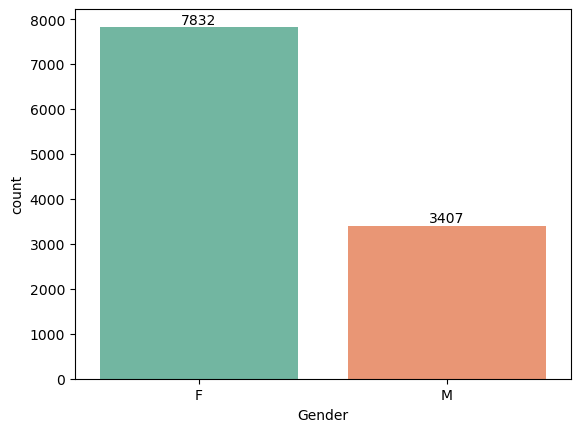

In [42]:
# shows the count (frequency) of each gender category in the buyers.
ax = sns.countplot(x = 'Gender',hue='Gender', data = df, palette='Set2',legend=False)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

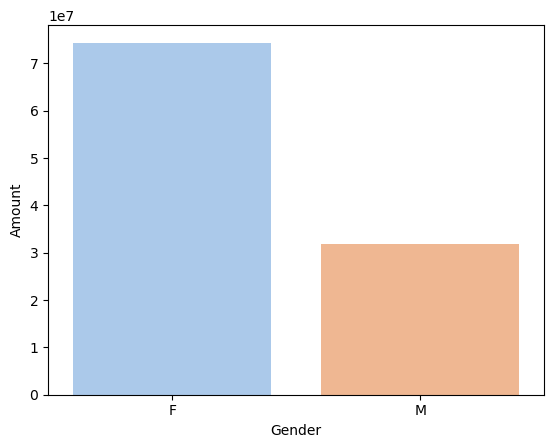

In [46]:
#shows the total sales amount contributed by each gender category.
Sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x = 'Gender',y = 'Amount', hue='Gender', data = Sales_gen, palette='pastel',legend=False)
plt.show() 

 **The graphs above clearly indicate that the majority of buyers are female, highlighting their greater purchasing power in this market.**

#### Age

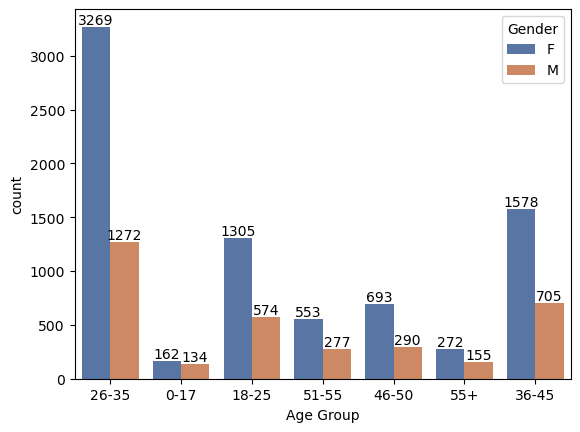

In [51]:
ax = sns.countplot(x = 'Age Group',hue='Gender', data = df, palette='deep')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()  

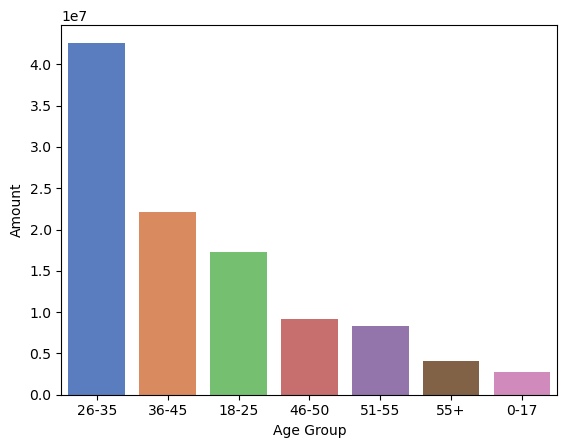

In [54]:
#shows which age group has spend more amount
Sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x = 'Age Group',y = 'Amount', hue='Age Group', data = Sales_age, palette='muted')
plt.show() 

**The graphs above shows that the majority of buyers are females in the 26-35 age group.**

#### State

In [55]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

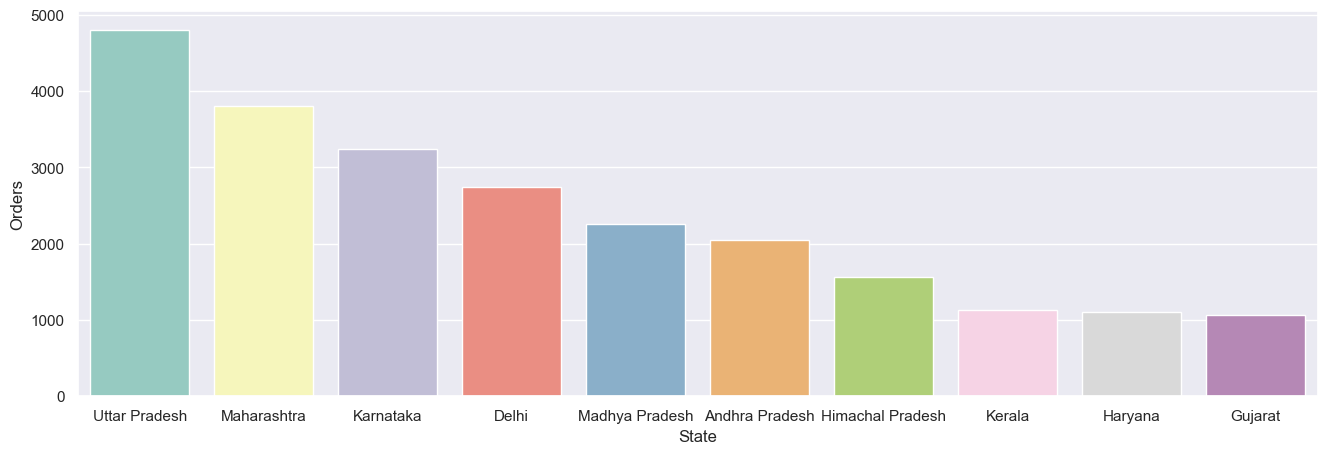

In [59]:
#Total number of orders from top 10 states
Sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sns.set(rc={'figure.figsize':(16,5)})
sns.barplot(x = 'State',y = 'Orders', hue='State', data = Sales_state, palette='Set3')
plt.show() 

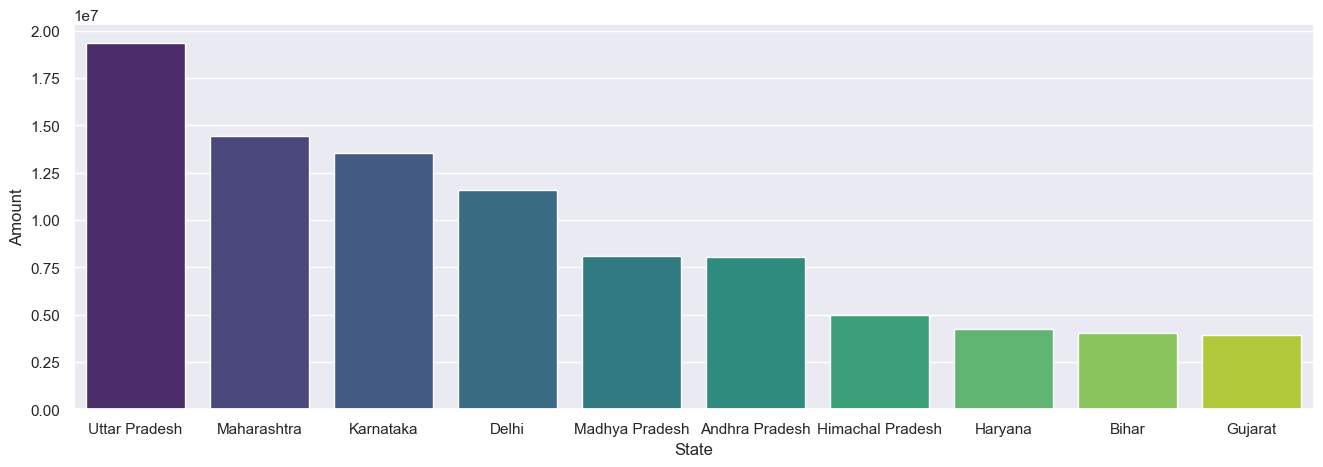

In [58]:
#Total amount/sales from top 10 states
Sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
sns.set(rc={'figure.figsize':(16,5)})
sns.barplot(x = 'State',y = 'Amount', hue='State', data = Sales_state, palette='viridis')
plt.show() 

**From the graphs above, we can observe that Uttar Pradesh, Maharashtra, and Karnataka respectively lead in both the number of orders and the total sales amount.**

#### Martial_Status

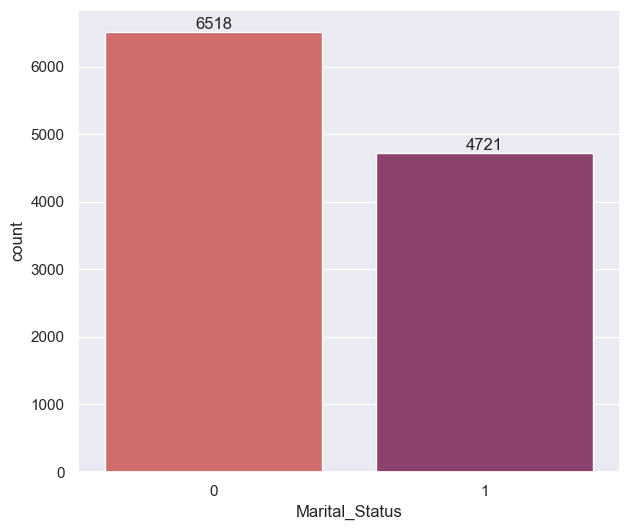

In [74]:
ax = sns.countplot(x = 'Marital_Status',hue='Marital_Status', data = df, palette='flare', legend=False)

sns.set(rc={'figure.figsize':(7,6)})
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()  

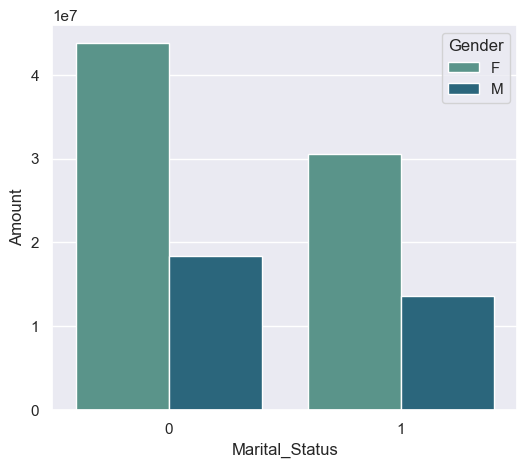

In [72]:
#Shows the total sales amount for each marital status and gender group
Sales_state = df.groupby(['Marital_Status','Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(x = 'Marital_Status',y = 'Amount', hue='Gender', data = Sales_state, palette='crest')
plt.show() 

**The above graphs indicate that the majority of buyers are married women who possess significant purchasing power.**

#### Occupation

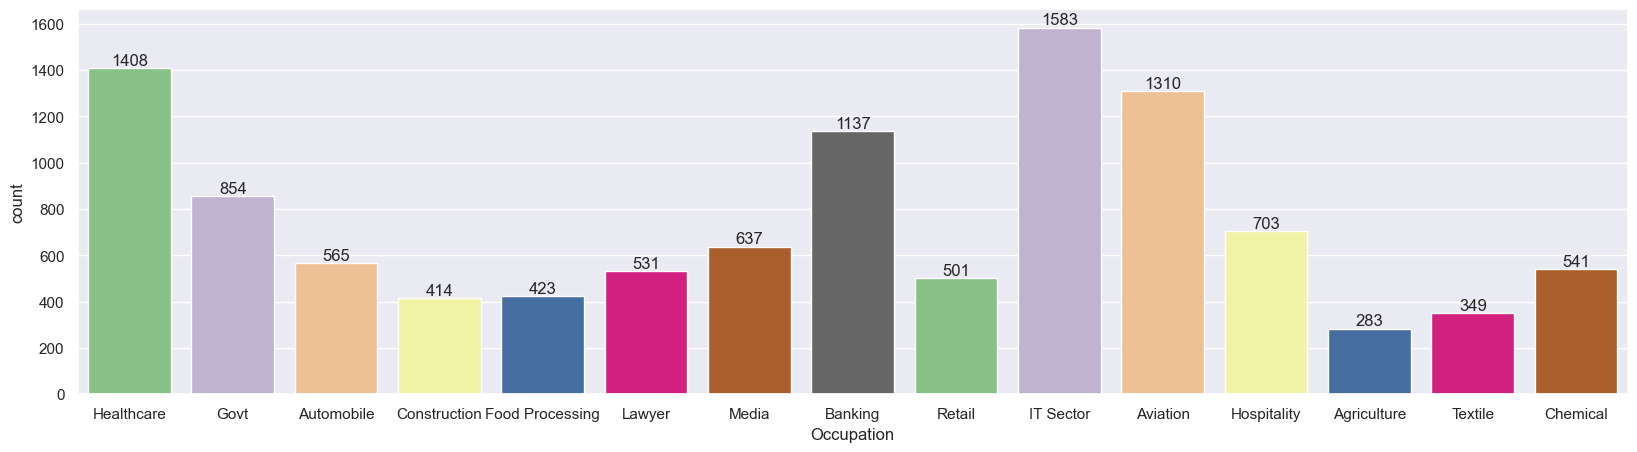

In [76]:
#shows which sectors placed more orders
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(x = 'Occupation', hue='Occupation', data = df, palette='Accent', legend=False)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show() 


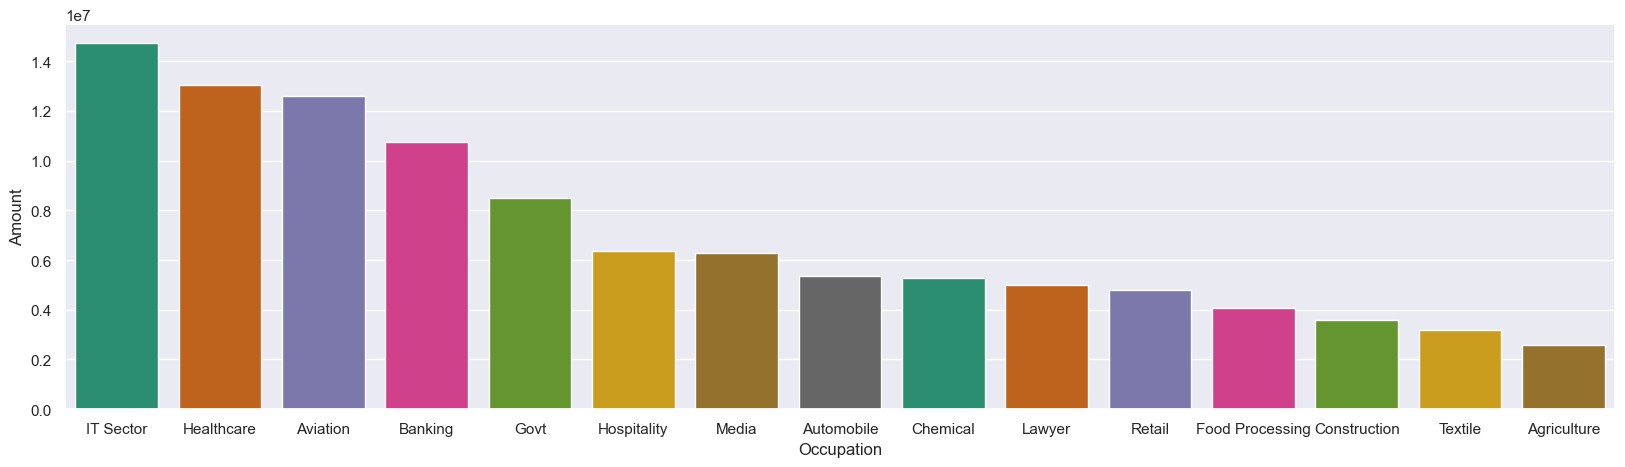

In [77]:
#shows which sector have highest purchasing power
Sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(x = 'Occupation',y = 'Amount', hue='Occupation', data = Sales_state, palette='Dark2')
plt.show() 

***The graphs above show that the majority of buyers come from the IT, Healthcare and Aviation sectors.***

#### Product Category

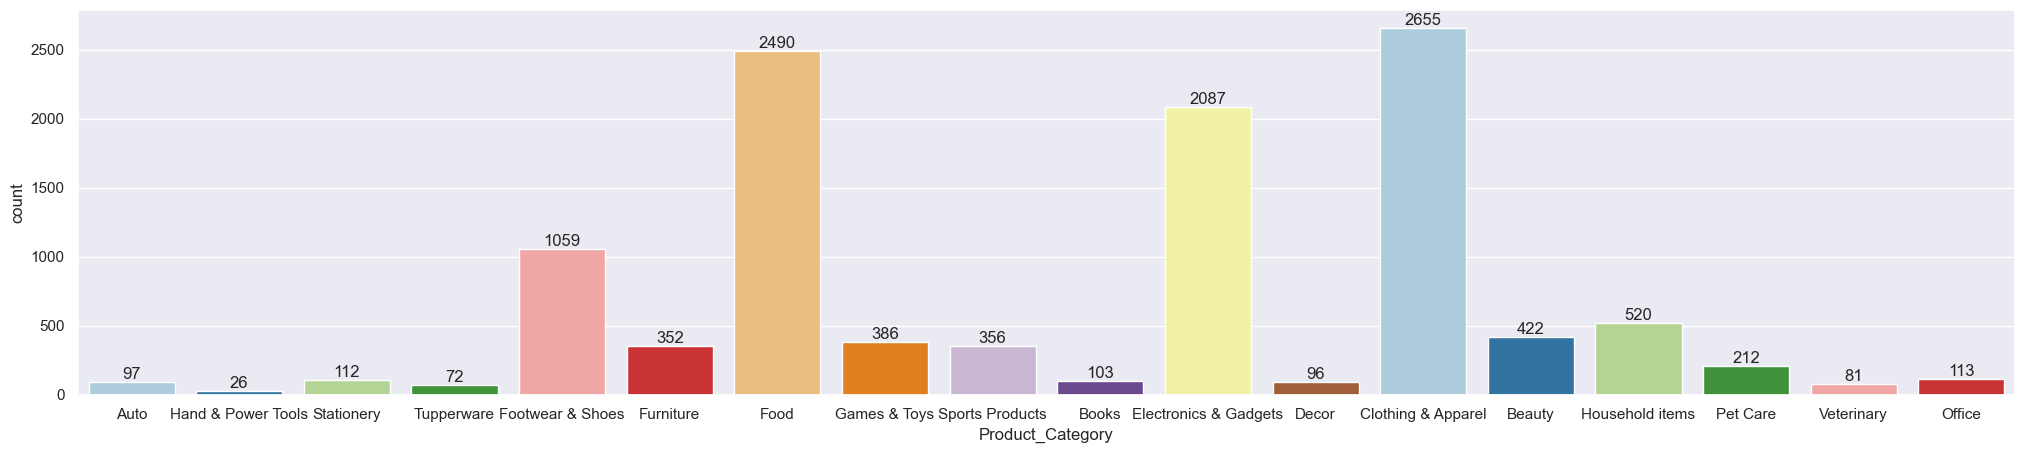

In [85]:
#Shows the product category with the highest sales
sns.set(rc={'figure.figsize':(25,5)})
ax = sns.countplot(x = 'Product_Category', hue='Product_Category', data = df, palette='Paired', legend=False)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show() 

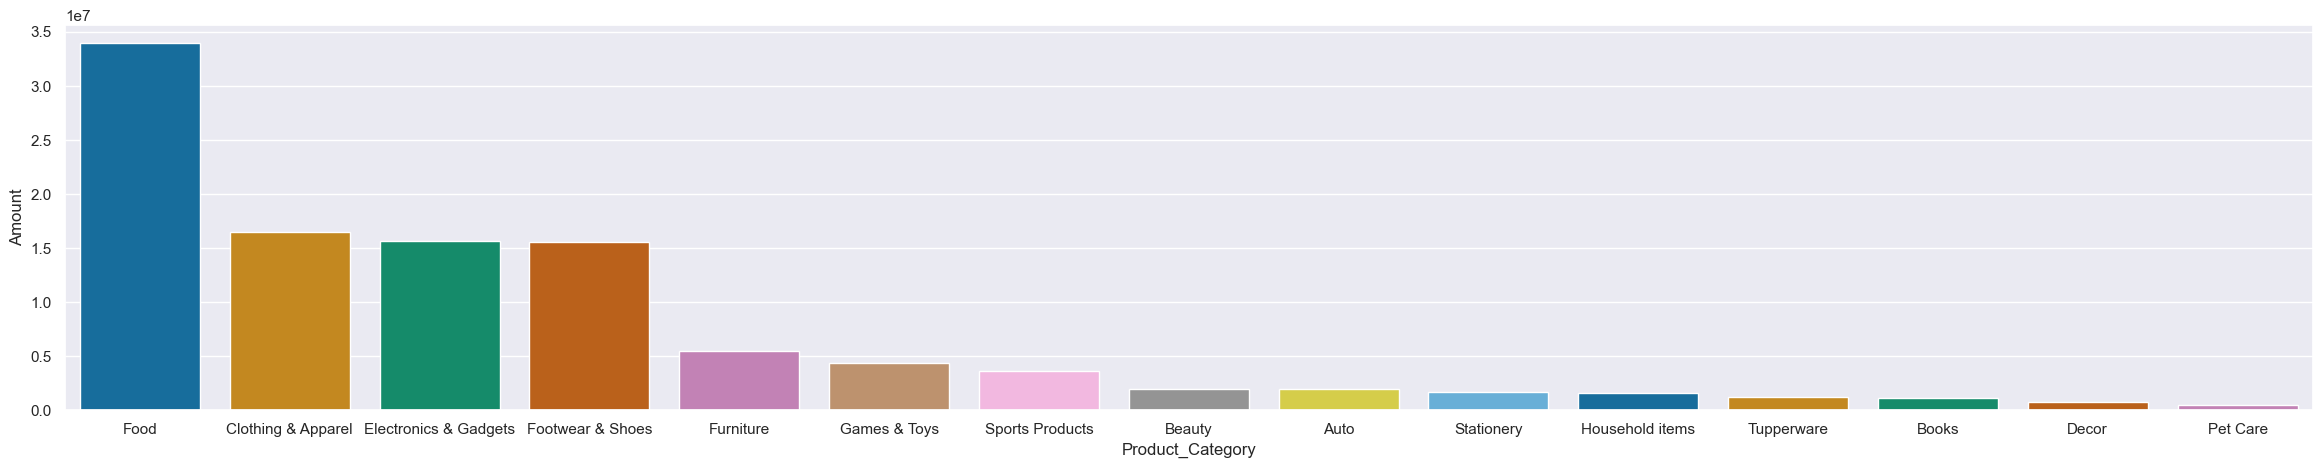

In [92]:
#Shows the category with the highest total spending
Sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(15)
sns.set(rc={'figure.figsize':(29,5)})
sns.barplot(x = 'Product_Category',y = 'Amount', hue='Product_Category', data = Sales_state, palette='colorblind')
plt.show() 

**The above graphs reveal that the majority of sold products belong to the Food, Clothing, and Electronics categories.**

### Conclusion
**Married women aged 26-35 years from Uttar Pradesh, Maharashtra, and Karnataka, working in IT, Healthcare, and Aviation sectors, are more likely to purchase products from the Food, Clothing, and Electronics categories.**